In [1]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime']
dfs = [pd.read_csv(f'../traces/expiry/fb_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.1) for c in ['a', 'b', 'c']]
df = pd.concat(dfs)
df = df[df['ttl'] != 0]
df

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime
0,69841,0,900,68489,1,68489,68489,0,0,0,28
1,72411,0,900,71420,1,71420,71420,0,0,0,28
2,84385,86695,900,83455,1,83455,83455,2,1,0,28
3,84590,0,900,83684,1,83684,83684,2,1,0,28
4,89237,0,900,88319,1,88319,88319,2,2,0,28
...,...,...,...,...,...,...,...,...,...,...,...
5955691,691326062,0,1209600,690115546,1,690115546,690115546,415086,415086,0,15
5955692,691326062,0,1209600,690115979,1,690115979,690115979,415086,415086,0,16
5955693,691326062,0,1209600,690116076,3,690116464,690116076,415086,415086,0,2
5955694,691326062,0,1209600,690116196,1,690116196,690116196,415086,415086,0,15


# feature engineering

In [3]:
def calc_features(df):
    df['should_reval'] = (df['ts'] <= df['next_ts']) & (df['next_ts'] <= (df['ts'] + df['ttl'])) & (df['ttl'] < 7 * 86400)
    df['generations'] = ((df['ts'] - df['create_ts'] - 1) / df['ttl']).round()
    df['t_since_last'] = df['ts'] - df['last_ts']
    df['t_since_last_frac'] = (df['t_since_last'] - 1)/ df['ttl']
    return df

calc_features(df)

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,should_reval,generations,t_since_last,t_since_last_frac
0,69841,0,900,68489,1,68489,68489,0,0,0,28,False,2.0,1352,1.501111
1,72411,0,900,71420,1,71420,71420,0,0,0,28,False,1.0,991,1.100000
2,84385,86695,900,83455,1,83455,83455,2,1,0,28,False,1.0,930,1.032222
3,84590,0,900,83684,1,83684,83684,2,1,0,28,False,1.0,906,1.005556
4,89237,0,900,88319,1,88319,88319,2,2,0,28,False,1.0,918,1.018889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955691,691326062,0,1209600,690115546,1,690115546,690115546,415086,415086,0,15,False,1.0,1210516,1.000756
5955692,691326062,0,1209600,690115979,1,690115979,690115979,415086,415086,0,16,False,1.0,1210083,1.000398
5955693,691326062,0,1209600,690116076,3,690116464,690116076,415086,415086,0,2,False,1.0,1209598,0.999998
5955694,691326062,0,1209600,690116196,1,690116196,690116196,415086,415086,0,15,False,1.0,1209866,1.000219


# training

In [4]:
from sklearn.model_selection import train_test_split
import skl2onnx
from skl2onnx.common.data_types import FloatTensorType
import pickle

# under-sample should revalidates
df_true = df[df['should_reval'] == True]
df_false = df[df['should_reval'] == False].sample(n=len(df_true) * 2, random_state=42)
df_true = df_true.sample(n=len(df_false), random_state=42, replace=True)
train_df = pd.concat([df_true, df_false])

def split_xy(df):
    y = df['should_reval']
    x = df[['ttl', 'freq', 'generations',
            't_since_last', 't_since_last_frac', 'mime']]
    return x, y


x, y = split_xy(train_df)
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.33, random_state = 42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rfc = RandomForestClassifier(n_estimators=32, criterion = 'gini', min_samples_leaf = 0.01, random_state=42, n_jobs=-1)
rfc.fit(x_train, y_train)
y_pred = rfc.predict(x_test)
print(f'Train acc: {accuracy_score(y_train, rfc.predict(x_train)):0.4f}')
print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')

gini = pd.Series(rfc.feature_importances_, index=x_train.columns).sort_values(ascending=False)
display(gini)
print(classification_report(y_test, y_pred))

Train acc: 0.8844
Test acc: 0.8831


ttl                  0.460295
t_since_last         0.372380
mime                 0.074030
t_since_last_frac    0.070658
generations          0.015027
freq                 0.007610
dtype: float64

              precision    recall  f1-score   support

       False       0.96      0.80      0.87    113032
        True       0.83      0.96      0.89    112568

    accuracy                           0.88    225600
   macro avg       0.89      0.88      0.88    225600
weighted avg       0.89      0.88      0.88    225600



ROC AUC: 0.9395
Average Precision (AP): 0.9234


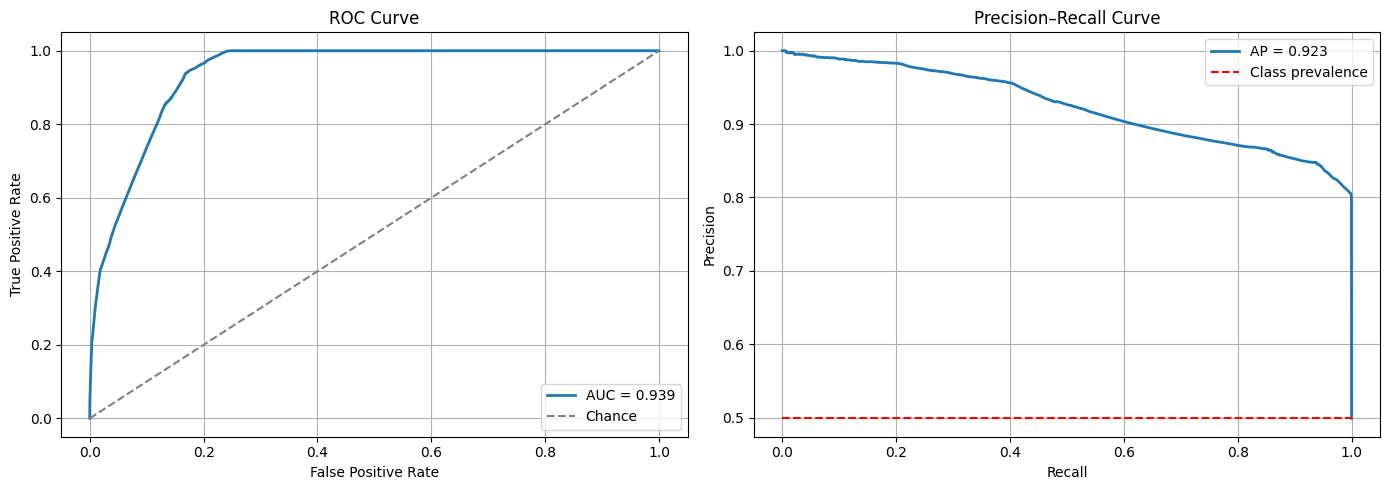

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = rfc.predict_proba(x_test)[:, 1]
fpr, tpr, roc_thresholds = roc_curve(y_test, y_scores)
auc_value = roc_auc_score(y_test, y_scores)
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
ap_value = average_precision_score(y_test, y_scores)

plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], '--', color='gray', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2, label=f"AP = {ap_value:.3f}")
plt.hlines(y_test.mean(), 0, 1, colors='red', linestyles='--', label="Class prevalence")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

print(f"ROC AUC: {auc_value:.4f}")
print(f"Average Precision (AP): {ap_value:.4f}")

In [12]:
name = 'rfc_fb_all_v4'
m = rfc

with open(f'../models/{name}.pkl', 'wb') as f:
    pickle.dump(m, f)

onnx = skl2onnx.to_onnx(
    m,
    initial_types=[('in', FloatTensorType([None, x_train.shape[1]]))],  # type: ignore
    options={'zipmap': False},
    verbose=1)
with open(f'../models/{name}.onnx', 'wb') as f:
    f.write(onnx.SerializeToString())  # type: ignore

# file size of the onnx model
import os
print(f'ONNX model size: {os.path.getsize(f"../models/{name}.onnx") / 1024:.2f} KB')

[to_onnx] initial_types=[('in', FloatTensorType(shape=[None, 6]))]
[convert_sklearn] parse_sklearn_model
[convert_sklearn] convert_topology
[convert_operators] begin
[convert_operators] iteration 1 - n_vars=0 n_ops=1
[call_converter] call converter for 'SklearnRandomForestClassifier'.
[convert_operators] end iter: 1 - n_vars=3
[convert_operators] iteration 2 - n_vars=3 n_ops=1
[convert_operators] end iter: 2 - n_vars=3
[convert_operators] end.
[_update_domain_version] +opset 0: name='ai.onnx.ml', version=1
[convert_topology] +opset: name='', version=21
[convert_sklearn] end
ONNX model size: 54.50 KB


In [8]:
# from sklearn.neural_network import MLPClassifier

# mlp = MLPClassifier(hidden_layer_sizes=(16, 32, 32, 16), max_iter=200, early_stopping=True, random_state=42)
# mlp.fit(x_train, y_train)

# y_pred = mlp.predict(x_test)
# print(f'Train acc: {accuracy_score(y_train, mlp.predict(x_train)):0.4f}')
# print(f'Test acc: {accuracy_score(y_test, y_pred):0.4f}')
# print(classification_report(y_test, y_pred))

# transferability

In [9]:
for subdf in dfs:
    subdf = calc_features(subdf)
    x, y = split_xy(subdf)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF acc: {acc:0.4f}')
    print(classification_report(y, y_pred))


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [ ]:
dfcftest = pd.read_csv(f'../traces/expiry/cf_a.csv.zst', names=cols, nrows=1000)
dfcftest = calc_features(dfcftest)
dfcftest.head()

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,should_reval,generations,t_since_last,t_since_last_frac
0,69841,0,900,68489,1,68489,68489,0,0,0,28,False,2.0,1352,1.501111
1,70517,0,900,69089,1,69089,69089,0,0,0,28,False,2.0,1428,1.585556
2,72411,0,900,71420,1,71420,71420,0,0,0,28,False,1.0,991,1.100000
3,73261,0,900,72250,1,72250,72250,0,0,0,28,False,1.0,1011,1.122222
4,74013,0,900,72990,1,72990,72990,0,0,0,28,False,1.0,1023,1.135556


In [ ]:
for c in ['a', 'c', 'e', 'g']:
    dfs = pd.read_csv(f'../traces/expiry/cf_{c}.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.005)
    dfs = calc_features(dfs)
    dfs = dfs[dfs['ttl'] != 0]
    x, y = split_xy(dfs)
    y_pred = rfc.predict(x)
    acc = accuracy_score(y, y_pred)
    print(f'CF {c} acc: {acc:0.4f}')
    print(classification_report(y, y_pred))

CF a acc: 0.9839
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    120608
        True       0.47      0.18      0.26      1917

    accuracy                           0.98    122525
   macro avg       0.73      0.59      0.63    122525
weighted avg       0.98      0.98      0.98    122525

CF b acc: 0.9871
              precision    recall  f1-score   support

       False       0.99      1.00      0.99    356504
        True       0.40      0.16      0.23      4332

    accuracy                           0.99    360836
   macro avg       0.70      0.58      0.61    360836
weighted avg       0.98      0.99      0.98    360836

CF c acc: 0.9924
              precision    recall  f1-score   support

       False       0.99      1.00      1.00    296126
        True       0.49      0.30      0.38      2238

    accuracy                           0.99    298364
   macro avg       0.74      0.65      0.69    298364
weighted avg       0.99

In [ ]:
dfwm = pd.read_csv(f'../traces/expiry/wm_t.csv.zst', names=cols, skiprows = lambda i : i > 0 and random.random() > 0.002)
dfwm = calc_features(dfwm)
dfwm = dfwm[dfwm['ttl'] != 0]
x, y = split_xy(dfwm)
y_pred = rfc.predict(x)
acc = accuracy_score(y, y_pred)
print(f'CF {c} acc: {acc:0.4f}')
print(classification_report(y, y_pred))

CF c acc: 0.7943
              precision    recall  f1-score   support

       False       0.78      0.91      0.84     56979
        True       0.83      0.62      0.71     38811

    accuracy                           0.79     95790
   macro avg       0.80      0.77      0.78     95790
weighted avg       0.80      0.79      0.79     95790

